In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from arch import arch_model
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

from data_wrangling import *

## Importing Data

In [2]:
xlu = pd.read_hdf("etf_series.hf5", key="XLU").Close

data_dxy = pd.read_csv("data/data_dxy.csv", index_col=0).Close
data_dxy.index = pd.to_datetime(data_dxy.index)
data_2yr = pd.read_csv("data/data_2yr.csv", index_col=0).Close
data_10yr = pd.read_csv("data/data_10yr.csv", index_col=0).Close
data_vix = pd.read_csv("data/data_vix.csv", index_col=0).Close
data_vix.index = pd.to_datetime(data_vix.index)

data_2s10s = data_2yr - data_10yr
data_2s10s.index = pd.to_datetime(data_2s10s.index)

In [3]:
print(xlu.info())
print("___")
print(data_dxy.info())
print("___")
print(data_2s10s.info())
print("___")
print(data_vix.info())

<class 'pandas.core.series.Series'>
DatetimeIndex: 6037 entries, 2000-01-03 to 2023-12-29
Series name: Close
Non-Null Count  Dtype  
--------------  -----  
6037 non-null   float64
dtypes: float64(1)
memory usage: 94.3 KB
None
___
<class 'pandas.core.series.Series'>
DatetimeIndex: 6064 entries, 2000-01-03 to 2023-12-29
Series name: Close
Non-Null Count  Dtype  
--------------  -----  
6064 non-null   float64
dtypes: float64(1)
memory usage: 94.8 KB
None
___
<class 'pandas.core.series.Series'>
DatetimeIndex: 6031 entries, 2000-01-03 to 2023-12-29
Series name: Close
Non-Null Count  Dtype  
--------------  -----  
6031 non-null   float64
dtypes: float64(1)
memory usage: 94.2 KB
None
___
<class 'pandas.core.series.Series'>
DatetimeIndex: 6037 entries, 2000-01-03 to 2023-12-29
Series name: Close
Non-Null Count  Dtype  
--------------  -----  
6037 non-null   float64
dtypes: float64(1)
memory usage: 94.3 KB
None


Uneven datasets, filtering the dataset to only show common dates

## Exploratory Data Analysis

In [4]:
dates_xlu = set(xlu.index)
dates_dxy = set(data_dxy.index)
dates_2s10s = set(data_2s10s.index)
dates_vix = set(data_vix.index)

common_dates = dates_xlu & dates_dxy & dates_2s10s & dates_vix
not_common_dates = (dates_xlu | dates_dxy | dates_2s10s | dates_vix) - common_dates

print(len(common_dates))
print(len(not_common_dates))

6030
36


In [5]:
xlu = xlu[xlu.index.isin(common_dates)]
data_dxy = data_dxy[data_dxy.index.isin(common_dates)]
data_2s10s = data_2s10s[data_2s10s.index.isin(common_dates)]
data_vix = data_vix[data_vix.index.isin(common_dates)]

xlu.shape[0] == data_vix.shape[0] == data_dxy.shape[0] == data_2s10s.shape[0]

True

First, attempt to difference stationary the data until stationary (less xlu, which we will use .pct_change)

In [6]:
# XLU
xlu_ret = xlu.pct_change().dropna()
if adf_test(xlu_ret) < 0.05:
    print("XLU is stationary")

XLU is stationary


In [7]:
# DXY
if adf_test(data_dxy) < 0.05:
    print("DXY is stationary")
else:
    print("DXY is not stationary")

d1_dxy = data_dxy.diff().dropna()
if adf_test(d1_dxy) < 0.05:
    print("D1 DXY is stationary")
else:
    print("D1 DXY is not stationary")

DXY is not stationary
D1 DXY is stationary


In [8]:
# 2s10s
if adf_test(data_2s10s) < 0.05:
    print("2s10s is stationary")
else:
    print("2s10s is not stationary")

d1_2s10s = data_2s10s.diff().dropna()
if adf_test(d1_2s10s) < 0.05:
    print("D1 2s10s is stationary")
else:
    print("D1 2s10s is not stationary")    

2s10s is not stationary
D1 2s10s is stationary


In [9]:
# VIX
if adf_test(data_vix) < 0.05:
    print("VIX is stationary")
else:
    print("VIX is not stationary")
# Even though VIX is stationary, we will use the first difference to completedness
d1_vix = data_vix.diff().dropna()
if adf_test(d1_vix) < 0.05:
    print("D1 VIX is stationary")
else:
    print("D1 VIX is not stationary")

VIX is stationary
D1 VIX is stationary


Goldfed-Quandt Test

In [10]:
print(goldfeld_quandt_test(d1_dxy, xlu_ret))
print(goldfeld_quandt_test(d1_2s10s, xlu_ret))
print(goldfeld_quandt_test(d1_vix, xlu_ret))

{'F-statistic': 0.7351178058977059, 'p-value': 0.9999999999999999}
{'F-statistic': 0.7389699690198983, 'p-value': 0.9999999999999999}
{'F-statistic': 0.8907754860751799, 'p-value': 0.9992456132758691}


Based on GQ. homoscedasticity is present for all data

In [11]:
print(white_test(d1_dxy, xlu_ret))
print(white_test(d1_2s10s, xlu_ret))
print(white_test(d1_vix, xlu_ret))

{'LM-statistic': 156.01004612792644, 'LM-test p-value': 1.3269327791792464e-34, 'F-statistic': 80.03730172797789, 'F-test p-value': 4.942013549340666e-35}
{'LM-statistic': 142.4796791749476, 'LM-test p-value': 1.1506169713538451e-31, 'F-statistic': 72.92785040347012, 'F-test p-value': 5.070664548786874e-32}
{'LM-statistic': 264.02159310544056, 'LM-test p-value': 4.660575045910677e-58, 'F-statistic': 137.9878646336866, 'F-test p-value': 2.5373739908050386e-59}


Based on White, heteroscedasticity is present for all data. <br>
We will use White's test as it makes less assumptions.

In [12]:
white_test(np.log(data_dxy).diff().dropna(), np.log(xlu).diff().dropna())

{'LM-statistic': 135.91871639191135,
 'LM-test p-value': 3.0593258886418544e-30,
 'F-statistic': 69.49218461111981,
 'F-test p-value': 1.4544723754048548e-30}

In [13]:
from scipy import stats

# Apply Box-Cox transformation
y_boxcox, _ = stats.boxcox(xlu.dropna())
X_boxcox, _ = stats.boxcox(data_dxy.dropna())

# Run White test again after Box-Cox
white_test(X_boxcox, y_boxcox)

{'LM-statistic': 1663.2624216769718,
 'LM-test p-value': 0.0,
 'F-statistic': 1147.8228810004243,
 'F-test p-value': 0.0}

Given that transformations attempts have failed, we will proceed with robust standard error estimation in our GARCH-X model <br>

## Plotting ACF and PACF

ACF

Text(0.5, 1.0, 'ACF of XLU')

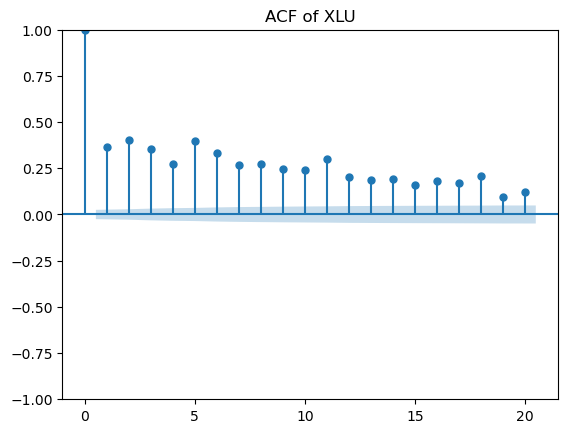

In [26]:
sm.graphics.tsa.plot_acf(xlu_ret**2, lags=20)
plt.title("ACF of XLU")

PACF

Text(0.5, 1.0, 'PACF of XLU')

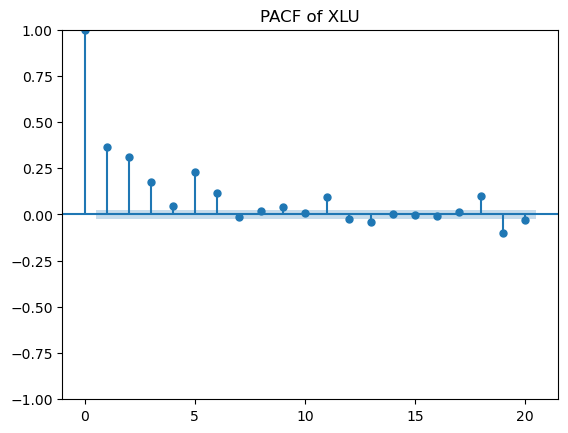

In [25]:
sm.graphics.tsa.plot_pacf(xlu_ret**2, lags=20)
plt.title("PACF of XLU")

## Data Preparation

In [20]:
comb_df = pd.concat([xlu_ret, d1_dxy, d1_2s10s, d1_vix], axis=1)
comb_df.columns = ["XLU", "D1 DXY", "D1 2s10s", "D1 VIX"]
X = comb_df[["D1 DXY", "D1 2s10s", "D1 VIX"]]
y = comb_df["XLU"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
y_scaled = pd.Series(y_scaled.flatten(), index=y.index)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, shuffle=False)

## Fitting an automatic ARIMA model

In [21]:
arima = pm.auto_arima(y=y_train, X=X_train, start_P=1, start_Q=1, seasonal=False)

In [22]:
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 4220
Model:               SARIMAX(1, 0, 1)   Log Likelihood               -5163.340
Date:                Fri, 08 Nov 2024   AIC                          10338.680
Time:                        18:59:21   BIC                          10376.765
Sample:                             0   HQIC                         10352.143
                               - 4220                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
D1 DXY        -0.0749      0.009     -8.181      0.000      -0.093      -0.057
D1 2s10s       0.0289      0.009      3.143      0.002       0.011       0.047
D1 VIX        -0.5545      0.008    -72.255      0.000      -0.570      -0.539
ar.L1         -0.4874      0.159     -3.060      0.002      -0.800      -0.175
ma.L1          0.4407      0.164      2.690      0.007       0.120       0.762
sigma2         0.6765      0.008     86.128      0.000       0.661       0.692
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              5550.79
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.41   Skew:                            -0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.62
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Fitting a GARCH-X (1,1) model

In [27]:
garch_x = arch_model(arima.resid(), mean="zero", vol="GARCH", dist="t", p=1, q=1)
garch_x_fit = garch_x.fit(disp="off", cov_type="robust")
garch_x_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Zero Mean - GARCH Model Results                           
====================================================================================
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -4544.94
Distribution:      Standardized Student's t   AIC:                           9097.89
Method:                  Maximum Likelihood   BIC:                           9123.28
                                              No. Observations:                 4220
Date:                      Fri, Nov 08 2024   Df Residuals:                     4220
Time:                              19:09:50   Df Model:                            0
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      5.3744e-03  1.966e-03      2.733  6.271e-03 [1.521e-03,9.228e-03]
alpha[1]       0.0608  1.092e-02      5.564  2.636e-08 [3.937e-02,8.219e-02]
beta[1]        0.9306  1.294e-02     71.907      0.000     [  0.905,  0.956]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu            10.8220      1.606      6.739  1.598e-11 [  7.674, 13.970]
========================================================================

Covariance estimator: robust
"""

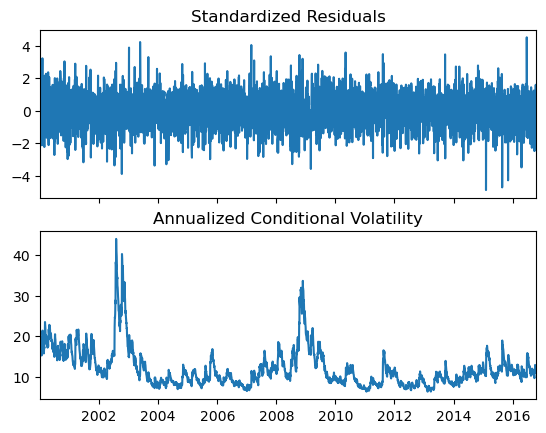

In [28]:
fig = garch_x_fit.plot(annualize="D")

In [29]:
garch_x_fit.model.volatility

GARCH(p: 1, q: 1), id: 0x28c45488d50

Ljung Box Test

In [30]:
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = garch_x_fit.resid
acorr_ljungbox(resid, lags=10)

# fail to reject null hypothesis, residuals are independent; autocorrelation is NOT present

,lb_stat,lb_pvalue
1,0.000767,0.977913
2,0.021632,0.989242
3,0.607104,0.894804
4,0.611964,0.961725
5,3.312060,0.651996
6,3.796116,0.704245
7,8.338053,0.303730
8,9.297913,0.317791
9,11.561373,0.239181
10,12.652684,0.243744


Durbin Watson Test

In [31]:
from statsmodels.stats.stattools import durbin_watson

durbin_watson(resid)
# No autocorrelation

1.9981888259515916

## Rolling Forecast

In [25]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")


pred = []
for i in range(len(X_test)):
    roll_x_train = X_scaled.iloc[:len(y_train)+i]
    roll_y_train = y_scaled.iloc[:len(y_train)+i]
    # arima = pm.auto_arima(y=roll_y_train, X=roll_x_train, start_P=1, start_Q=1, seasonal=False)
    # arima = pm.ARIMA(order=(1, 0, 1))
    arima = ARIMA(roll_y_train, order=(1, 0, 1), exog=roll_x_train)
    arima_result = arima.fit()
    garch_x = arch_model(arima_result.resid, mean="zero", vol="Garch", p=1, q=1)
    garch_x_fit = garch_x.fit(disp="off", cov_type="robust")
    pred.append(np.sqrt(garch_x_fit.forecast(horizon=1).variance.values[-1,:][0]))
    print(f"Pred for {roll_x_train.index[-1]} completed")

Pred for 2016-10-19 00:00:00 completed
Pred for 2016-10-20 00:00:00 completed
Pred for 2016-10-21 00:00:00 completed
Pred for 2016-10-24 00:00:00 completed
Pred for 2016-10-25 00:00:00 completed
Pred for 2016-10-26 00:00:00 completed
Pred for 2016-10-27 00:00:00 completed
Pred for 2016-10-28 00:00:00 completed
Pred for 2016-10-31 00:00:00 completed
Pred for 2016-11-01 00:00:00 completed
Pred for 2016-11-02 00:00:00 completed
Pred for 2016-11-03 00:00:00 completed
Pred for 2016-11-04 00:00:00 completed
Pred for 2016-11-07 00:00:00 completed
Pred for 2016-11-08 00:00:00 completed
Pred for 2016-11-09 00:00:00 completed
Pred for 2016-11-10 00:00:00 completed
Pred for 2016-11-14 00:00:00 completed
Pred for 2016-11-15 00:00:00 completed
Pred for 2016-11-16 00:00:00 completed
Pred for 2016-11-17 00:00:00 completed
Pred for 2016-11-18 00:00:00 completed
Pred for 2016-11-21 00:00:00 completed
Pred for 2016-11-22 00:00:00 completed
Pred for 2016-11-23 00:00:00 completed
Pred for 2016-11-25 00:00

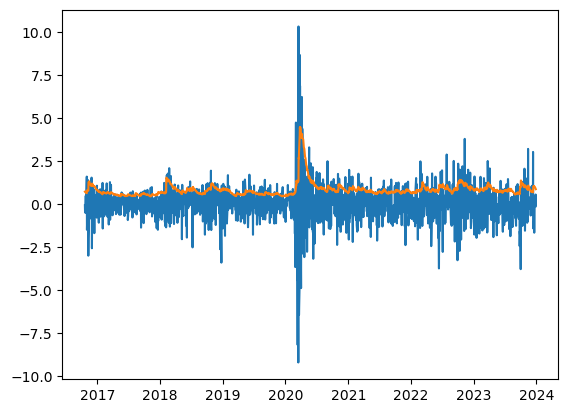

In [26]:
pred_df = pd.Series(pred, index=X_test.index)
plt.plot(y_test)
plt.plot(pred_df)

## Evaluating Metrics

In [27]:
def evaluate_smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred))/2
    return "sMAPE :", np.mean(numerator/denominator) * 100

def evaluate_rmse(y_true, y_pred):
    squared_errors = (y_true - y_pred)**2
    rmse = np.sqrt(np.mean(squared_errors))
    return "RMSE (squared residuals vs predicted variance):", rmse

In [28]:
print(evaluate_rmse(y_test, pred_df))
print(evaluate_smape(y_test, pred_df))

('RMSE (squared residuals vs predicted variance):', 1.390164658094378)
('sMAPE :', 132.6688374798695)


In [29]:
pred_df.to_csv("data/XLU_pred.csv")